# All Sites Forcing Data Figure 

created by Cassie Lumbrazo\
last updated: June 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.dates as mdates

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [3]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [5]:
# HRRR-AK Files First 
ds_snowpack_hrrrak_ppsa, header_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_tram, header_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_tram_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_heen, header_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/hrrrak_heen_WY2020-WY2025_base.smet")

# HRRR-AK Lapse-rate Files 
ds_snowpack_hrrrak_lapserate_ppsa, header_hrrrak_lapserate_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_lapserate_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_lapserate_tram, header_hrrrak_lapserate_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_lapserate_tram_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_lapserate_heen, header_hrrrak_lapserate_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/hrrrak_lapserate_heen_WY2020-WY2025_base.smet")

# Met HRRR-AK Files now
ds_snowpack_met_hrrrak_ppsa, header_met_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025
ds_snowpack_met_hrrrak_tram, header_met_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_tram_WY2023-WY2025_base.smet") # tram has WY2023-WY2025
ds_snowpack_met_hrrrak_heen, header_met_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/met_hrrrak_heen_WY2020-WY2022_base.smet") # heen doesn't have until 2025 

# Met HRRR-AK Lapse-rate Files
# ds_snowpack_met_hrrrak_lapserate_ppsa, header_met_hrrrak_lapserate_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_lapserate_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025
# ds_snowpack_met_hrrrak_lapserate_tram, header_met_hrrrak_lapserate_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_lapserate_tram_WY2023-WY2025_base.smet")
# ds_snowpack_met_hrrrak_lapserate_heen, header_met_hrrrak_lapserate_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/met_hrrrak_lapserate_heen_WY2020-WY2022_base.smet") # heen doesn't have until 2025


# selecting the same time period for all datasets to make plotting easier
ds_snowpack_hrrrak_ppsa = ds_snowpack_hrrrak_ppsa.sel(timestamp=slice("2022-10-01", "2025-09-30"))
ds_snowpack_hrrrak_tram = ds_snowpack_hrrrak_tram.sel(timestamp=slice("2022-10-01", "2025-09-30"))
ds_snowpack_hrrrak_heen = ds_snowpack_hrrrak_heen.sel(timestamp=slice("2019-10-01", "2022-09-30"))

ds_snowpack_hrrrak_lapserate_ppsa = ds_snowpack_hrrrak_lapserate_ppsa.sel(timestamp=slice("2022-10-01", "2025-09-30"))
ds_snowpack_hrrrak_lapserate_tram = ds_snowpack_hrrrak_lapserate_tram.sel(timestamp=slice("2022-10-01", "2025-09-30"))
ds_snowpack_hrrrak_lapserate_heen = ds_snowpack_hrrrak_lapserate_heen.sel(timestamp=slice("2019-10-01", "2022-09-30"))

ds_snowpack_met_hrrrak_ppsa = ds_snowpack_met_hrrrak_ppsa.sel(timestamp=slice("2022-10-01", "2025-09-30"))
ds_snowpack_met_hrrrak_tram = ds_snowpack_met_hrrrak_tram.sel(timestamp=slice("2022-10-01", "2025-09-30"))
ds_snowpack_met_hrrrak_heen = ds_snowpack_met_hrrrak_heen.sel(timestamp=slice("2019-10-01", "2022-09-30"))

# ds_snowpack_met_hrrrak_lapserate_ppsa = ds_snowpack_met_hrrrak_lapserate_ppsa.sel(timestamp=slice("2022-10-01", "2025-09-30"))
# ds_snowpack_met_hrrrak_lapserate_tram = ds_snowpack_met_hrrrak_lapserate_tram.sel(timestamp=slice("2022-10-01", "2025-09-30"))
# ds_snowpack_met_hrrrak_lapserate_heen = ds_snowpack_met_hrrrak_lapserate_heen.sel(timestamp=slice("2019-10-01", "2022-09-30"))

/tmp/ipykernel_1626879/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1626879/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1626879/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


/tmp/ipykernel_1626879/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1626879/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1626879/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1626879/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1626879/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df 

### Open Observations

In [ ]:
# open observations
#PPSA 
file_ppsa = "/hdd/snow_hydrology/met_station/ppsa2/pppsa_met_station_data_synoptic_2026-03-20" 
ds_obs_ppsa = xr.open_dataset(file_ppsa)
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2019-10-01", "2025-09-30"))

# TRAM 
file_tram = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  
ds_obs_tram = xr.open_dataset(file_tram)
ds_obs_tram = ds_obs_tram.sel(time=slice("2019-10-01", "2025-09-30"))

# HEEN 
file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/heen_met_2016_2026_cleaned_v1.nc"
ds_obs_heen = xr.open_dataset(file_heen)
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-10-01", "2025-09-30"))

# selecting the same time period for all datasets to make plotting easier
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2022-10-01", "2025-09-30"))
ds_obs_tram = ds_obs_tram.sel(time=slice("2022-10-01", "2025-09-30"))
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-10-01", "2022-09-30"))

# HEEN obs temp is in K, convert to C 
ds_obs_heen["temp"] = ds_obs_heen["temp"] - 273.15

### Open HRRR-AK Data

In [ ]:
# OPEN HRRR-AK NETCDF FILES
# PPSA
input_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_ppsa.nc"
ds_hrrr_ppsa = xr.open_dataset(input_file)
ds_hrrr_ppsa.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work
ds_hrrr_ppsa = ds_hrrr_ppsa.sel(time=slice("2022-10-01", "2025-09-30"))
ds_hrrr_ppsa['precip_accum_1hr'] = ds_hrrr_ppsa['precip_rate'] * 3600 # convert from mm/s to mm/hr for comparison with the observed data
ds_hrrr_ppsa['temp'] = ds_hrrr_ppsa['temp'] - 273.15 # convert from K to C for comparison with the observed data

# TRAM
input_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tram.nc"
ds_hrrr_tram = xr.open_dataset(input_file)
ds_hrrr_tram.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work
ds_hrrr_tram = ds_hrrr_tram.sel(time=slice("2022-10-01", "2025-09-30"))
ds_hrrr_tram['precip_accum_1hr'] = ds_hrrr_tram['precip_rate'] * 3600 # convert from mm/s to mm/hr for comparison with the observed data
ds_hrrr_tram['temp'] = ds_hrrr_tram['temp'] - 273.15 # convert from K to C for comparison with the observed data

# HEEN
input_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_heen.nc"
ds_hrrr_heen = xr.open_dataset(input_file)
ds_hrrr_heen.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work
ds_hrrr_heen = ds_hrrr_heen.sel(time=slice("2019-10-01", "2022-09-30"))
ds_hrrr_heen['precip_accum_1hr'] = ds_hrrr_heen['precip_rate'] * 3600 # convert from mm/s to mm/hr for comparison with the observed data
ds_hrrr_heen['temp'] = ds_hrrr_heen['temp'] - 273.15 # convert from K to C for comparison with the observed data

### Plotting Constants 

In [ ]:
# pick colors for each site and stick to them across all plots
ppsa_color = 'darkviolet'
tram_color = 'maroon'
heen_color = 'teal'

# color hrrr-ak model 
hrrrak_color = 'tab:blue'
met_hrrrak_color = 'tab:green'
obs_color = 'tab:gray'

In [ ]:
ds_obs_heen

<xarray.Dataset> Size: 2MB
Dimensions:           (time: 23506)
Coordinates:
  * time              (time) datetime64[ns] 188kB 2019-10-01 ... 2022-09-30T2...
Data variables:
    swe               (time) float64 188kB ...
    temp              (time) float64 188kB ...
    hs                (time) float64 188kB ...
    rh                (time) float64 188kB ...
    precip_accum      (time) float64 188kB ...
    wind              (time) float64 188kB ...
    wind_dir          (time) float64 188kB ...
    pressure          (time) float64 188kB ...
    precip_rate       (time) float64 188kB ...
    precip_accum_1hr  (time) float64 188kB ...

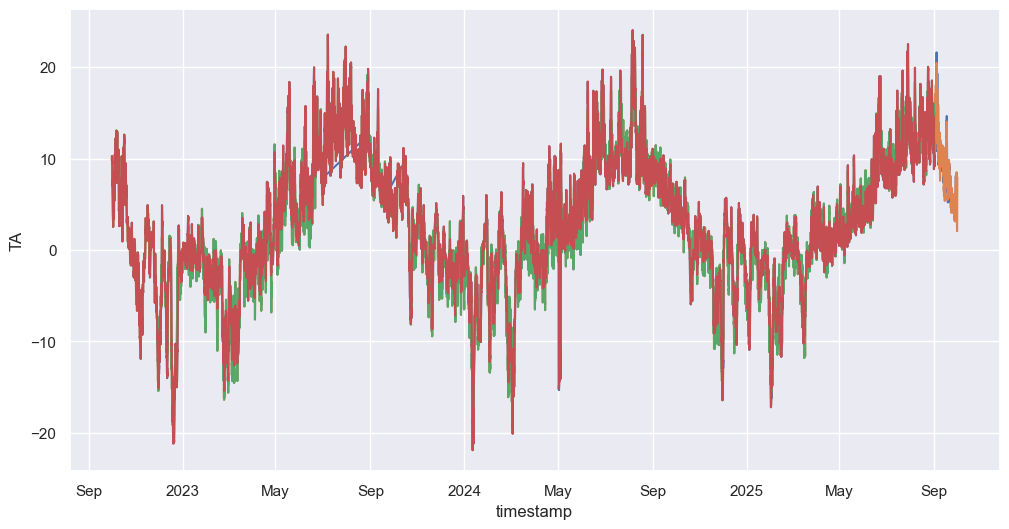

In [ ]:
ds_obs_ppsa.temp.plot()
ds_hrrr_ppsa.temp.plot()
ds_snowpack_hrrrak_ppsa.TA.plot()
ds_snowpack_met_hrrrak_ppsa.TA.plot()

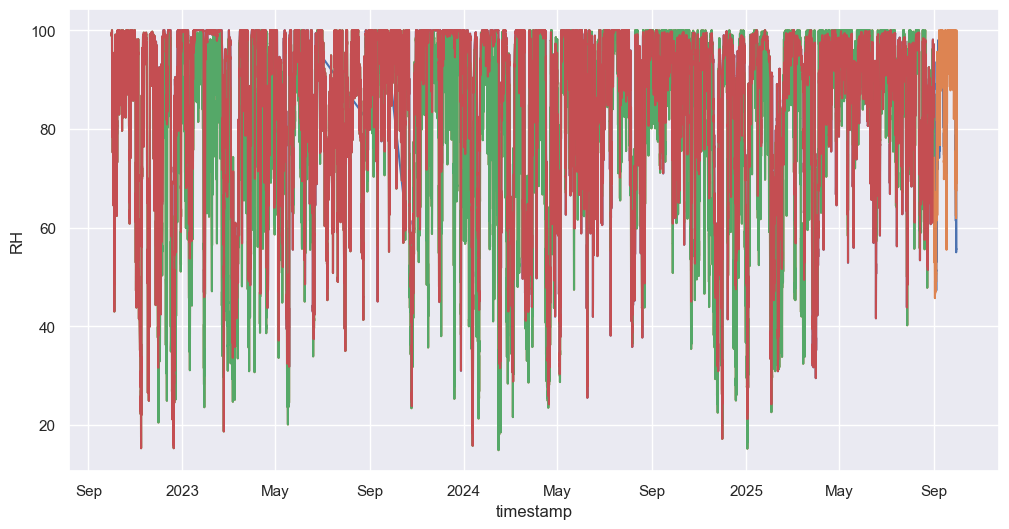

In [ ]:
ds_obs_ppsa.rh.plot()
ds_hrrr_ppsa.rh.plot()
ds_snowpack_hrrrak_ppsa.RH.plot()
ds_snowpack_met_hrrrak_ppsa.RH.plot()

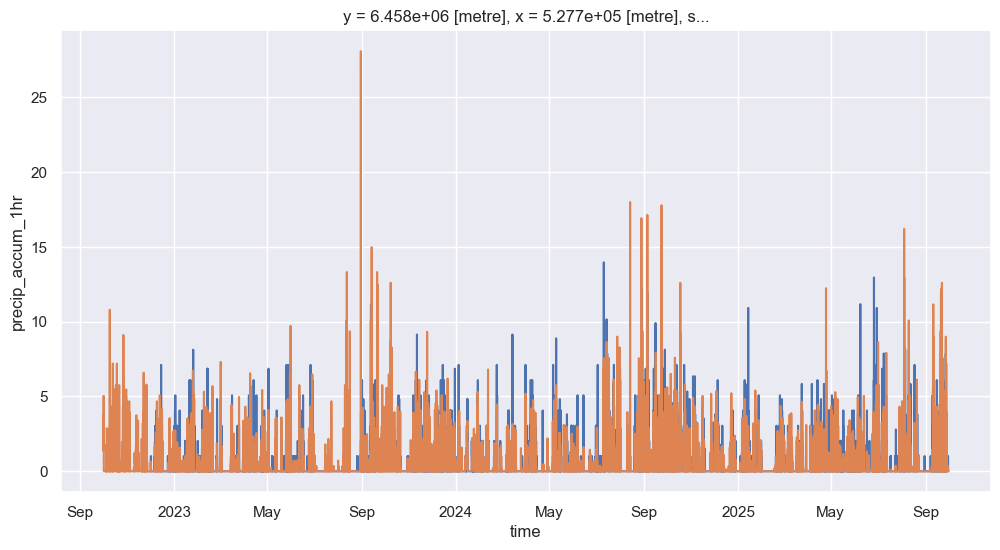

In [ ]:
ds_obs_ppsa.precip_accum_1hr.plot()
ds_hrrr_ppsa.precip_accum_1hr.plot()
# ds_snowpack_hrrrak_ppsa.PSUM24.plot()
# ds_snowpack_met_hrrrak_ppsa.PSUM24.plot()

# Figure 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar

# =============================================================================
# USER SETTINGS
# =============================================================================

fontsize = 12

hrrrak_color = 'tab:blue'
obs_color = 'black'

linewidth = 2

site_names = ['PPSA', 'TRAM', 'HEEN']
var_names = ['temp', 'rh', 'precip_accum_1hr']

var_labels = {
    'temp': 'air temperature (°C)',
    'rh': 'relative humidity (%)',
    'precip_accum_1hr': 'precipitation (mm hr$^{-1}$)'
}

month_labels = [
    f'{calendar.month_abbr[m]}\n2025' if m == 1 else calendar.month_abbr[m]
    for m in range(1, 13)
]

# =============================================================================
# DATASETS
# =============================================================================

hrrr_datasets = {
    'PPSA': ds_hrrr_ppsa,
    'TRAM': ds_hrrr_tram,
    'HEEN': ds_hrrr_heen
}

obs_datasets = {
    'PPSA': ds_obs_ppsa,
    'TRAM': ds_obs_tram,
    'HEEN': ds_obs_heen
}

# =============================================================================
# FIGURE
# =============================================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(12, 9),
    sharex=True
)

for col, site in enumerate(site_names):

    ds_hrrr = hrrr_datasets[site]
    ds_obs = obs_datasets[site]

    for row, var in enumerate(var_names):

        ax = axes[row, col]

        # ---------------------------------------------------------
        # Monthly climatology
        # ---------------------------------------------------------

        hrrr_monthly = (
            ds_hrrr[var]
            .groupby('time.month')
            .mean(skipna=True)
        )

        obs_monthly = (
            ds_obs[var]
            .groupby('time.month')
            .mean(skipna=True)
        )

        # ---------------------------------------------------------
        # Plot
        # ---------------------------------------------------------

        ax.plot(
            hrrr_monthly['month'],
            hrrr_monthly,
            color=hrrrak_color,
            lw=linewidth,
            label='HRRR-AK'
        )

        ax.plot(
            obs_monthly['month'],
            obs_monthly,
            color=obs_color,
            lw=linewidth,
            label='Observed'
        )

        # ---------------------------------------------------------
        # Formatting
        # ---------------------------------------------------------

        ax.set_xlim(1, 12)

        ax.set_xticks(np.arange(1, 13))
        ax.set_xticklabels(month_labels)

        ax.tick_params(
            axis='both',
            labelsize=fontsize
        )

        if col == 0:
            ax.set_ylabel(
                var_labels[var],
                fontsize=fontsize
            )

        if row == 0:
            ax.set_title(
                site,
                fontsize=fontsize + 2,
                fontweight='bold'
            )

        ax.grid(
            True,
            alpha=0.3
        )

# =============================================================================
# SINGLE LEGEND
# =============================================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.92),
    ncol=2,
    fontsize=fontsize
)

plt.suptitle(
    "Monthly Climatology of HRRR-AK vs. Observed Forcing",
    fontsize=fontsize + 4,
    fontweight='bold',
    y=0.97
)
plt.tight_layout(rect=[0, 0, 1, 0.88])

plt.show()

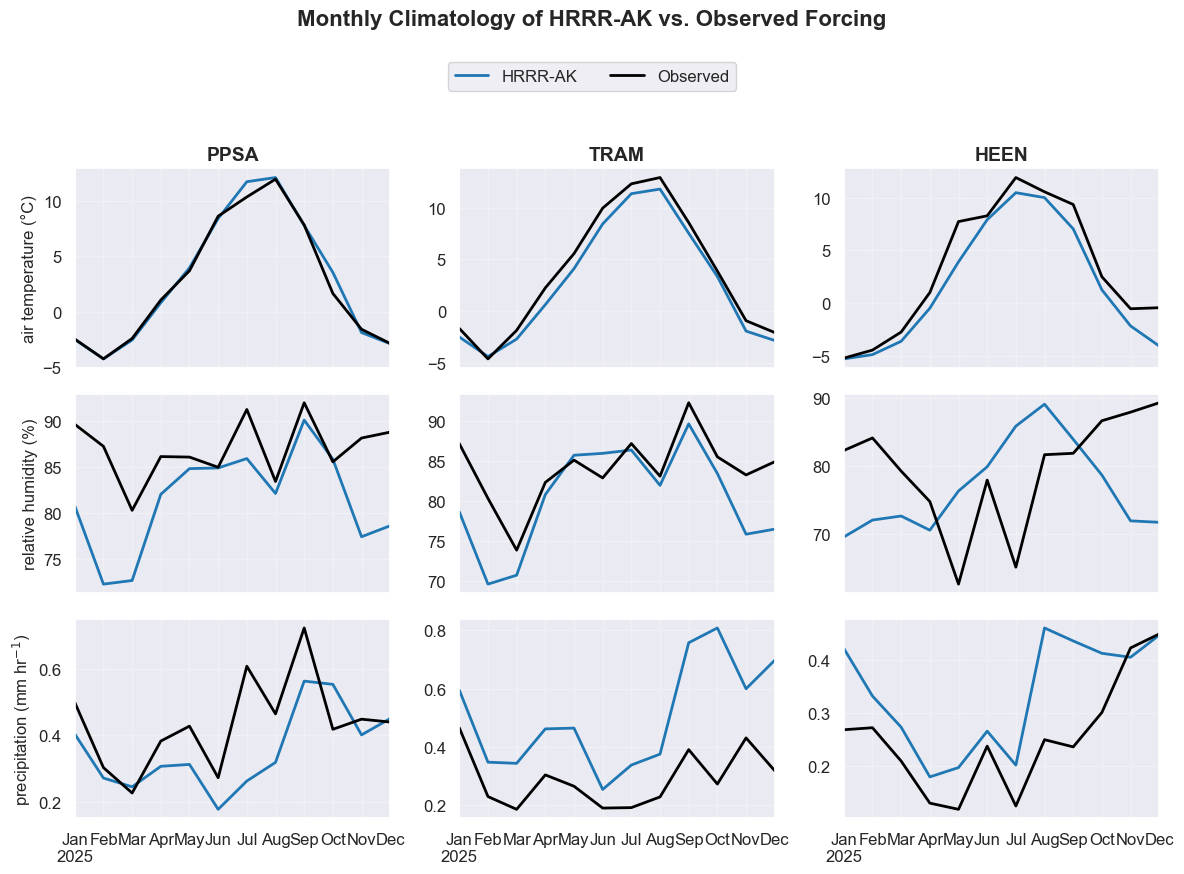

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar

# =============================================================================
# USER SETTINGS
# =============================================================================

fontsize = 12

hrrrak_color = 'tab:blue'
obs_color = 'black'

linewidth = 2

site_names = ['PPSA', 'TRAM', 'HEEN']
var_names = ['temp', 'rh', 'precip_accum_1hr']

var_labels = {
    'temp': 'air temperature (°C)',
    'rh': 'relative humidity (%)',
    'precip_accum_1hr': 'precipitation (mm hr$^{-1}$)'
}

month_labels = [
    f'{calendar.month_abbr[m]}\n2025' if m == 1 else calendar.month_abbr[m]
    for m in range(1, 13)
]

# =============================================================================
# DATASETS
# =============================================================================

hrrr_datasets = {
    'PPSA': ds_hrrr_ppsa,
    'TRAM': ds_hrrr_tram,
    'HEEN': ds_hrrr_heen
}

obs_datasets = {
    'PPSA': ds_obs_ppsa,
    'TRAM': ds_obs_tram,
    'HEEN': ds_obs_heen
}

# =============================================================================
# FIGURE
# =============================================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(12, 9),
    sharex=True
)

for col, site in enumerate(site_names):

    ds_hrrr = hrrr_datasets[site]
    ds_obs = obs_datasets[site]

    for row, var in enumerate(var_names):

        ax = axes[row, col]

        # ---------------------------------------------------------
        # Monthly climatology
        # ---------------------------------------------------------

        hrrr_monthly = (
            ds_hrrr[var]
            .groupby('time.month')
            .mean(skipna=True)
        )

        obs_monthly = (
            ds_obs[var]
            .groupby('time.month')
            .mean(skipna=True)
        )

        # ---------------------------------------------------------
        # Plot
        # ---------------------------------------------------------

        ax.plot(
            hrrr_monthly['month'],
            hrrr_monthly,
            color=hrrrak_color,
            lw=linewidth,
            label='HRRR-AK'
        )

        ax.plot(
            obs_monthly['month'],
            obs_monthly,
            color=obs_color,
            lw=linewidth,
            label='Observed'
        )

        # ---------------------------------------------------------
        # Formatting
        # ---------------------------------------------------------

        ax.set_xlim(1, 12)

        ax.set_xticks(np.arange(1, 13))
        ax.set_xticklabels(month_labels)

        ax.tick_params(
            axis='both',
            labelsize=fontsize
        )

        if col == 0:
            ax.set_ylabel(
                var_labels[var],
                fontsize=fontsize
            )

        if row == 0:
            ax.set_title(
                site,
                fontsize=fontsize + 2,
                fontweight='bold'
            )

        ax.grid(
            True,
            alpha=0.3
        )

# =============================================================================
# SINGLE LEGEND
# =============================================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.92),
    ncol=2,
    fontsize=fontsize
)

plt.suptitle(
    "Monthly Climatology of HRRR-AK vs. Observed Forcing",
    fontsize=fontsize + 4,
    fontweight='bold',
    y=0.97
)
plt.tight_layout(rect=[0, 0, 1, 0.88])

plt.show()

Trying something else, 

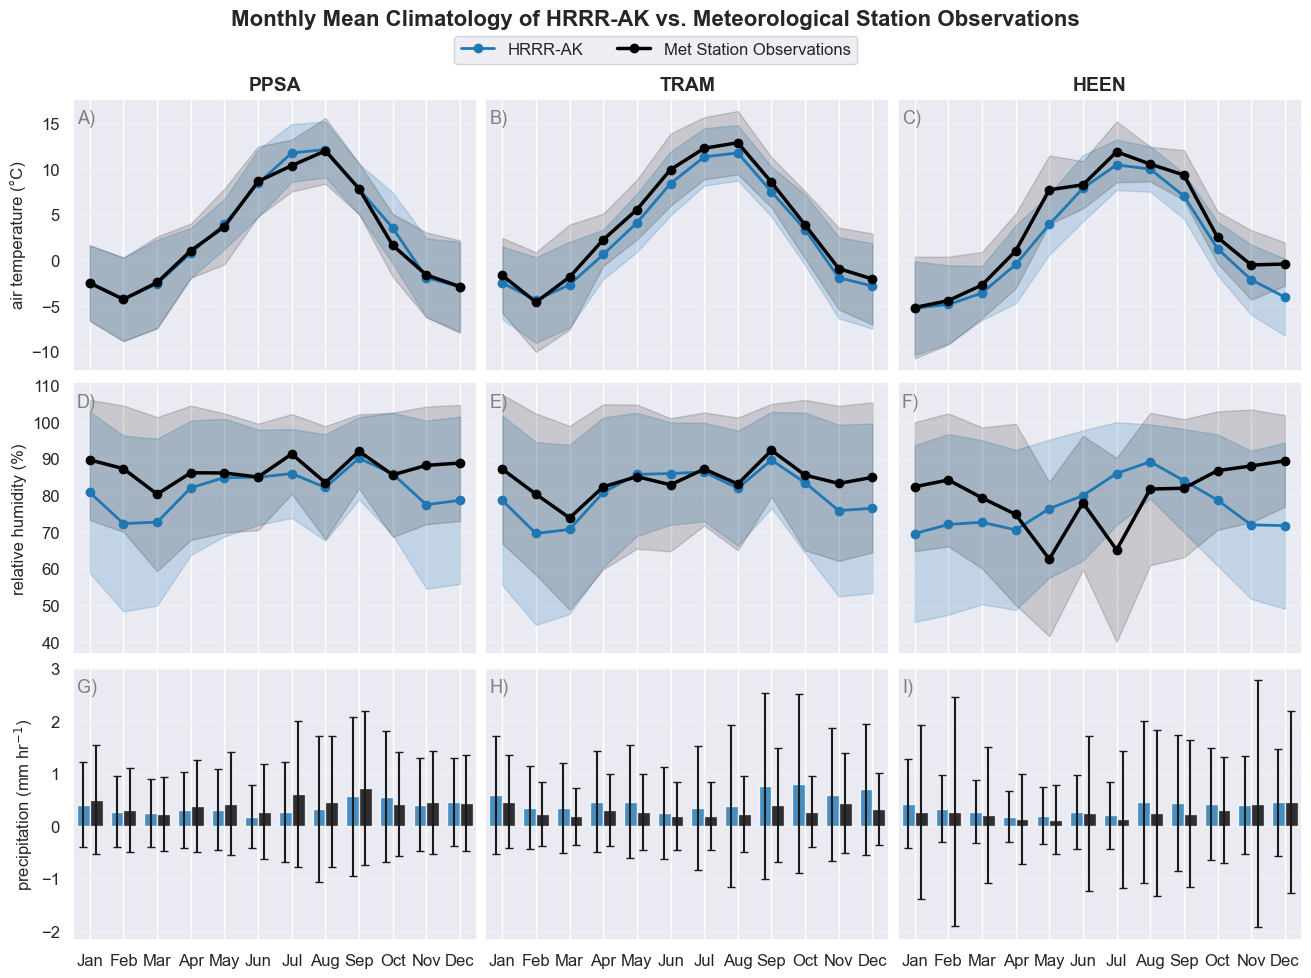

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# USER SETTINGS
# =============================================================================

fontsize = 12

hrrrak_color = 'tab:blue'
obs_color = 'black'

linewidth_hrrr = 2
linewidth_obs = 2.5

alpha_hrrr = 0.20
alpha_obs = 0.15

figsize = (13, 9)

# =============================================================================
# DATASETS
# =============================================================================

hrrr_datasets = {
    'PPSA': ds_hrrr_ppsa,
    'TRAM': ds_hrrr_tram,
    'HEEN': ds_hrrr_heen
}

obs_datasets = {
    'PPSA': ds_obs_ppsa,
    'TRAM': ds_obs_tram,
    'HEEN': ds_obs_heen
}

site_names = ['PPSA', 'TRAM', 'HEEN']

var_names = [
    'temp',
    'rh',
    'precip_accum_1hr'
]

var_labels = {
    'temp': 'air temperature (°C)',
    'rh': 'relative humidity (%)',
    'precip_accum_1hr': 'precipitation (mm hr$^{-1}$)'
}

month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

# letters = list('abcdefghi')
letters = list('ABCDEFGHI') # capital letters for panel labels

# =============================================================================
# FIGURE
# =============================================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=figsize,
    sharex=True,
    sharey='row',
    constrained_layout=True
)

# =============================================================================
# LOOP THROUGH SITES AND VARIABLES
# =============================================================================

for col, site in enumerate(site_names):

    ds_hrrr = hrrr_datasets[site]
    ds_obs = obs_datasets[site]

    for row, var in enumerate(var_names):

        ax = axes[row, col]

        # ==========================================================
        # MONTHLY CLIMATOLOGY
        # ==========================================================

        hrrr_mean = (
            ds_hrrr[var]
            .groupby('time.month')
            .mean(skipna=True)
        )

        hrrr_std = (
            ds_hrrr[var]
            .groupby('time.month')
            .std(skipna=True)
        )

        obs_mean = (
            ds_obs[var]
            .groupby('time.month')
            .mean(skipna=True)
        )

        obs_std = (
            ds_obs[var]
            .groupby('time.month')
            .std(skipna=True)
        )

        # ==========================================================
        # TEMPERATURE AND RH
        # ==========================================================

        if var != 'precip_accum_1hr':

            ax.fill_between(
                hrrr_mean.month,
                hrrr_mean - hrrr_std,
                hrrr_mean + hrrr_std,
                color=hrrrak_color,
                alpha=alpha_hrrr
            )

            ax.fill_between(
                obs_mean.month,
                obs_mean - obs_std,
                obs_mean + obs_std,
                color=obs_color,
                alpha=alpha_obs
            )

            ax.plot(
                hrrr_mean.month,
                hrrr_mean,
                color=hrrrak_color,
                lw=linewidth_hrrr,
                marker='o',
                label='HRRR-AK'
            )

            ax.plot(
                obs_mean.month,
                obs_mean,
                color=obs_color,
                lw=linewidth_obs,
                marker='o',
                label='Met Station Observations'
            )

        # ==========================================================
        # PRECIPITATION
        # ==========================================================

        else:

            months = np.arange(1, 13)

            width = 0.38

            ax.bar(
                months - width/2,
                hrrr_mean,
                width,
                color=hrrrak_color,
                alpha=0.8,
                yerr=hrrr_std,
                capsize=3,
                label='HRRR-AK'
            )

            ax.bar(
                months + width/2,
                obs_mean,
                width,
                color=obs_color,
                alpha=0.8,
                yerr=obs_std,
                capsize=3,
                label='Met Station Observations'
            )

        # ==========================================================
        # AXIS FORMATTING
        # ==========================================================

        ax.set_xlim(0.5, 12.5)

        ax.set_xticks(np.arange(1, 13))
        ax.set_xticklabels(month_labels)

        ax.tick_params(
            axis='both',
            labelsize=fontsize
        )

        ax.grid(
            axis='y',
            alpha=0.3
        )

        # ----------------------------------------------------------
        # Panel labels
        # ----------------------------------------------------------

        panel_num = row * 3 + col

        ax.text(
            0.01,
            0.96,
            f'{letters[panel_num]})',
            transform=ax.transAxes,
            fontsize=fontsize +1,
            # fontweight='bold',
            va='top',
            color='gray'
        )

        # ----------------------------------------------------------
        # Row labels
        # ----------------------------------------------------------

        if col == 0:

            ax.set_ylabel(
                var_labels[var],
                fontsize=fontsize
            )

        # ----------------------------------------------------------
        # Column titles
        # ----------------------------------------------------------

        if row == 0:

            ax.set_title(
                site,
                fontsize=fontsize + 2,
                fontweight='bold'
            )

# =============================================================================
# SINGLE LEGEND
# =============================================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=2,
    fontsize=fontsize,
    bbox_to_anchor=(0.5, 1.05),

)

plt.suptitle(
    "Monthly Mean Climatology of HRRR-AK vs. Meteorological Station Observations",
    fontsize=fontsize + 4,
    fontweight='bold',
    y=1.07
)

plt.show()

## Interchangeable Code 

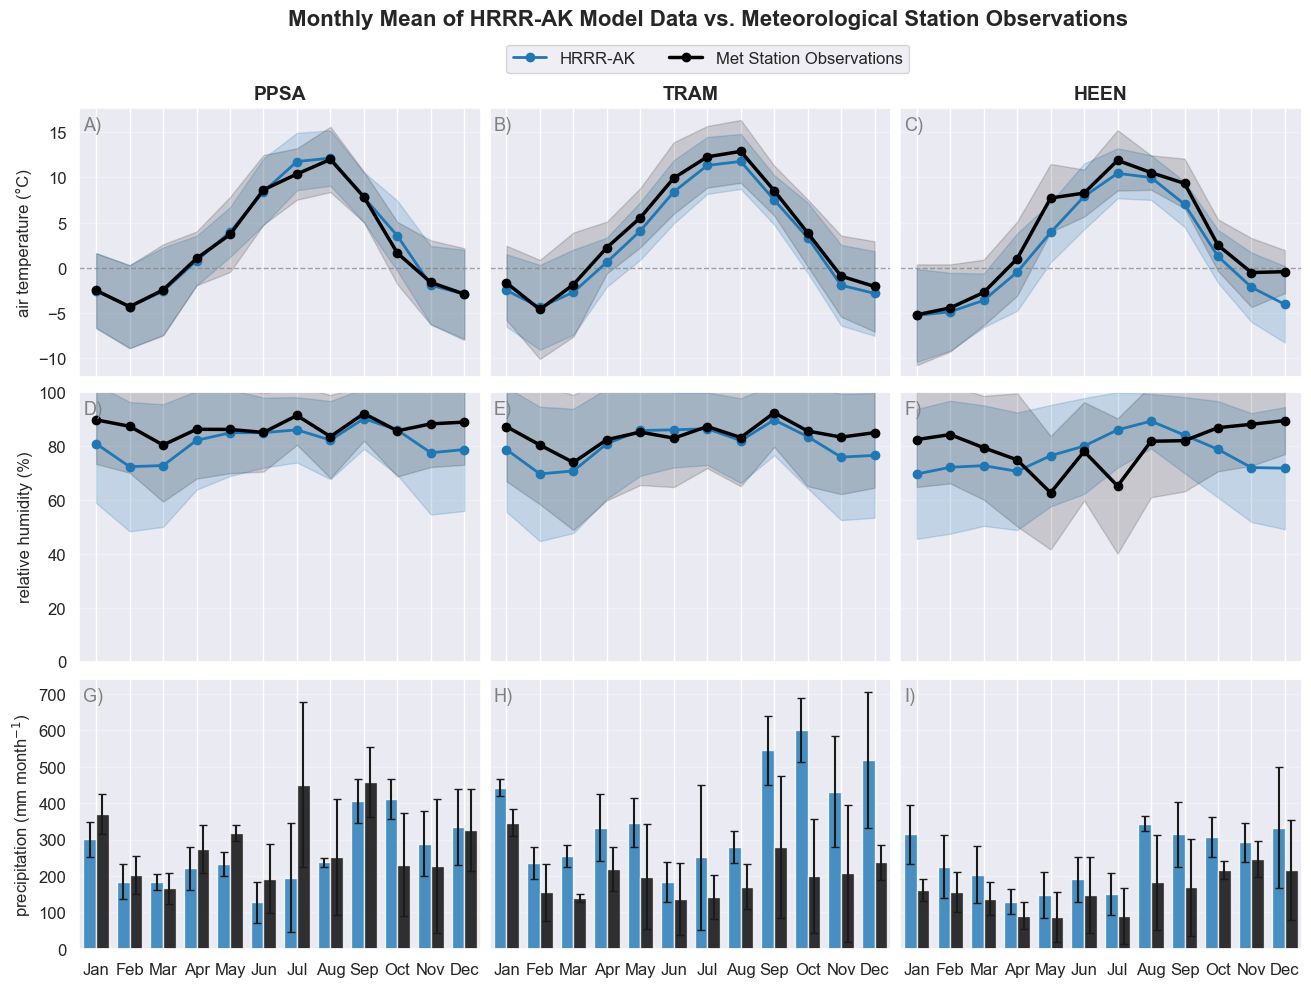

In [ ]:
# =============================================================================
# PRECIPITATION DISPLAY OPTION
# =============================================================================

# 'hourly_mean'   = mean hourly precipitation rate for each month
# 'monthly_total' = mean monthly accumulated precipitation climatology

precip_mode = 'monthly_total'
# precip_mode = 'hourly_mean'



import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# USER SETTINGS
# =============================================================================

fontsize = 12

hrrrak_color = 'tab:blue'
obs_color = 'black'

linewidth_hrrr = 2
linewidth_obs = 2.5

alpha_hrrr = 0.20
alpha_obs = 0.15

figsize = (13, 9)

# =============================================================================
# DATASETS
# =============================================================================

hrrr_datasets = {
    'PPSA': ds_hrrr_ppsa,
    'TRAM': ds_hrrr_tram,
    'HEEN': ds_hrrr_heen
}

obs_datasets = {
    'PPSA': ds_obs_ppsa,
    'TRAM': ds_obs_tram,
    'HEEN': ds_obs_heen
}

site_names = ['PPSA', 'TRAM', 'HEEN']

var_names = [
    'temp',
    'rh',
    'precip_accum_1hr'
]

var_labels = {
    'temp': 'air temperature (°C)',
    'rh': 'relative humidity (%)',
    'precip_accum_1hr': 'precipitation (mm hr$^{-1}$)'
}

month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

# letters = list('abcdefghi')
letters = list('ABCDEFGHI') # capital letters for panel labels

# =============================================================================
# FIGURE
# =============================================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=figsize,
    sharex=True,
    sharey='row',
    constrained_layout=True
)

# =============================================================================
# LOOP THROUGH SITES AND VARIABLES
# =============================================================================

for col, site in enumerate(site_names):

    ds_hrrr = hrrr_datasets[site]
    ds_obs = obs_datasets[site]

    for row, var in enumerate(var_names):

        ax = axes[row, col]
        
        # add a line at temp = 0 for reference in the temperature plots
        if var == 'temp':

            ax.axhline(
                0,
                color='gray',
                lw=1,
                ls='--',
                alpha=0.7
            )

        # ==========================================================
        # MONTHLY CLIMATOLOGY
        # ==========================================================

        # ----------------------------------------------------------
        # Temperature and Relative Humidity
        # ----------------------------------------------------------

        if var != 'precip_accum_1hr':

            hrrr_mean = (
                ds_hrrr[var]
                .groupby('time.month')
                .mean(skipna=True)
            )

            hrrr_std = (
                ds_hrrr[var]
                .groupby('time.month')
                .std(skipna=True)
            )

            obs_mean = (
                ds_obs[var]
                .groupby('time.month')
                .mean(skipna=True)
            )

            obs_std = (
                ds_obs[var]
                .groupby('time.month')
                .std(skipna=True)
            )

        # ----------------------------------------------------------
        # Precipitation
        # ----------------------------------------------------------

        else:

            # ======================================================
            # OPTION 1:
            # Mean hourly precipitation rate climatology
            #
            # Units:
            # mm hr-1
            # ======================================================

            if precip_mode == 'hourly_mean':

                hrrr_mean = (
                    ds_hrrr[var]
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                hrrr_std = (
                    ds_hrrr[var]
                    .groupby('time.month')
                    .std(skipna=True)
                )

                obs_mean = (
                    ds_obs[var]
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                obs_std = (
                    ds_obs[var]
                    .groupby('time.month')
                    .std(skipna=True)
                )

            # ======================================================
            # OPTION 2:
            # Monthly accumulated precipitation climatology
            #
            # Units:
            # mm month-1
            # ======================================================

            elif precip_mode == 'monthly_total':

                # --------------------------------------------------
                # HRRR monthly totals
                # --------------------------------------------------

                hrrr_monthly = (
                    ds_hrrr[var]
                    .resample(time='MS')
                    .sum(skipna=True)
                )

                hrrr_coverage = (
                    ds_hrrr[var]
                    .notnull()
                    .resample(time='MS')
                    .mean()
                )

                # Require at least 90% coverage
                hrrr_monthly = hrrr_monthly.where(
                    hrrr_coverage >= 0.90
                )

                hrrr_mean = (
                    hrrr_monthly
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                hrrr_std = (
                    hrrr_monthly
                    .groupby('time.month')
                    .std(skipna=True)
                )

                # --------------------------------------------------
                # Observation monthly totals
                # --------------------------------------------------

                obs_monthly = (
                    ds_obs[var]
                    .resample(time='MS')
                    .sum(skipna=True)
                )

                obs_coverage = (
                    ds_obs[var]
                    .notnull()
                    .resample(time='MS')
                    .mean()
                )

                # Require at least 90% coverage
                obs_monthly = obs_monthly.where(
                    obs_coverage >= 0.90
                )

                obs_mean = (
                    obs_monthly
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                obs_std = (
                    obs_monthly
                    .groupby('time.month')
                    .std(skipna=True)
                )

            else:

                raise ValueError(
                    "precip_mode must be 'hourly_mean' or 'monthly_total'"
                )
                
                
        # ==========================================================
        # TEMPERATURE AND RH
        # ==========================================================

        if var != 'precip_accum_1hr':

            ax.fill_between(
                hrrr_mean.month,
                hrrr_mean - hrrr_std,
                hrrr_mean + hrrr_std,
                color=hrrrak_color,
                alpha=alpha_hrrr
            )

            ax.fill_between(
                obs_mean.month,
                obs_mean - obs_std,
                obs_mean + obs_std,
                color=obs_color,
                alpha=alpha_obs
            )

            ax.plot(
                hrrr_mean.month,
                hrrr_mean,
                color=hrrrak_color,
                lw=linewidth_hrrr,
                marker='o',
                label='HRRR-AK'
            )

            ax.plot(
                obs_mean.month,
                obs_mean,
                color=obs_color,
                lw=linewidth_obs,
                marker='o',
                label='Met Station Observations'
            )
            


        # ==========================================================
        # PRECIPITATION
        # ==========================================================

        else:

            months = np.arange(1, 13)

            width = 0.38

            ax.bar(
                months - width/2,
                hrrr_mean,
                width,
                color=hrrrak_color,
                alpha=0.8,
                yerr=hrrr_std,
                capsize=3,
                label='HRRR-AK'
            )

            ax.bar(
                months + width/2,
                obs_mean,
                width,
                color=obs_color,
                alpha=0.8,
                yerr=obs_std,
                capsize=3,
                label='Met Station Observations'
            )

        # ==========================================================
        # AXIS FORMATTING
        # ==========================================================

        ax.set_xlim(0.5, 12.5)

        ax.set_xticks(np.arange(1, 13))
        ax.set_xticklabels(month_labels)

        ax.tick_params(
            axis='both',
            labelsize=fontsize
        )

        ax.grid(
            axis='y',
            alpha=0.3
        )

        # ----------------------------------------------------------
        # Panel labels A), B), C), etc.
        # ----------------------------------------------------------

        panel_num = row * 3 + col

        ax.text(
            0.01,
            0.97,
            f'{letters[panel_num]})',
            transform=ax.transAxes,
            fontsize=fontsize +1,
            # fontweight='bold',
            va='top',
            color='gray'
        )

        # ----------------------------------------------------------
        # Row labels
        # ----------------------------------------------------------

        if col == 0:

            ax.set_ylabel(
                var_labels[var],
                fontsize=fontsize
            )
            
            
        if precip_mode == 'monthly_total':
            precip_label = 'precipitation (mm month$^{-1}$)'
        else:
            precip_label = 'precipitation (mm hr$^{-1}$)'

        var_labels = {
        'temp': 'air temperature (°C)',
        'rh': 'relative humidity (%)',
        'precip_accum_1hr': precip_label
        }       

        # ----------------------------------------------------------
        # Column titles
        # ----------------------------------------------------------

        if row == 0:

            ax.set_title(
                site,
                fontsize=fontsize + 2,
                fontweight='bold'
            )

# =============================================================================
# SINGLE LEGEND
# =============================================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=2,
    fontsize=fontsize,
    bbox_to_anchor=(0.54, 1.05),

)

# limit the yaxis of the relative humidity plots to 0-100%
axes[1, 0].set_ylim(0, 100)
axes[1, 1].set_ylim(0, 100)
axes[1, 2].set_ylim(0, 100)

plt.suptitle(
    "Monthly Mean of HRRR-AK Model Data vs. Meteorological Station Observations",
    fontsize=fontsize + 4,
    fontweight='bold',
    x=0.54,
    y=1.08
)

plt.show()